In [5]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
import matplotlib.patheffects as pe
from scipy.integrate import solve_ivp
import matplotlib as mpl
from dataclasses import dataclass
import os


mpl.rcParams.update({
    "text.usetex": False,       # keep your sizes stable
    "mathtext.fontset": "cm",   # Computer Modern for math only
    # keep your normal font choice as-is (optional)
    # "font.family": "sans-serif",
    # "font.sans-serif": ["DejaVu Sans"],
})

## Fig 1. No feedback baseline (fixed game)

### Baseline game with no environmental feedback

$$M = \begin{bmatrix}
0 & \beta \\
\alpha & 0
\end{bmatrix}
$$

\begin{eqnarray}
\dot{x} = x(1-x)(-(\alpha+\beta)x+\alpha)
\end{eqnarray}

#### Panel A. Stability diagram in the payoff-parameter space ($\alpha, \beta$)

In [6]:
# phase diagram
def classify(alpha, beta):
    """Output:
       0 -> strategy 1 dominates (x=0 stable)
       1 -> strategy 2 dominates (x=1 stable)
       2 -> coexistence (interior stable)
       3 -> coordination/bistability (0 and 1 stable)
      -1 -> on axes (alpha=0 or beta=0)
    """
    if alpha < 0 and beta > 0:
        return 0
    if alpha > 0 and beta < 0:
        return 1
    if alpha > 0 and beta > 0:
        return 2
    if alpha < 0 and beta < 0:
        return 3
    return -1

A = np.linspace(-1, 1, 201)
B = np.linspace(-1, 1, 201)
AA, BB = np.meshgrid(A, B)
Z = np.zeros_like(AA, dtype=float)
for i in range(AA.shape[0]):
    for j in range(AA.shape[1]):
        Z[i, j] = classify(AA[i, j], BB[i, j])

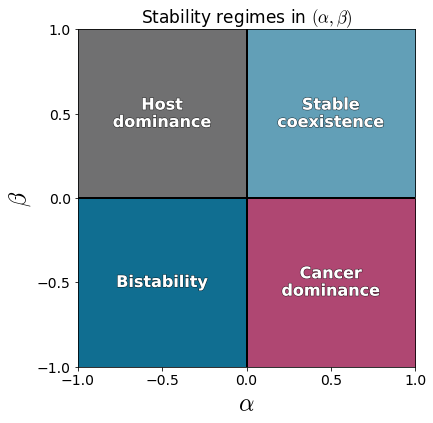

In [7]:
COL_HOST    = "#707071"   # host dominance
COL_COEX    = "#629FB7"   # stable coexistence
COL_BISTAB  = "#106E91"   # bistability
COL_CANCER  = "#AF4772"   # cancer dominance

# 0 host dom, 1 cancer dom, 2 coexist, 3 bistability
cmap = ListedColormap([COL_HOST, COL_CANCER, COL_COEX, COL_BISTAB])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

Z_masked = Z.astype(float)
Z_masked[Z_masked < 0] = np.nan  # hide alpha=0 or beta=0 cells

fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(
    Z_masked,
    origin="lower",
    extent=[A.min(), A.max(), B.min(), B.max()],
    aspect="equal",
    cmap=cmap,
    norm=norm,
    interpolation="nearest"
)

ax.axhline(0.001, linewidth=2, color='black')
ax.axvline(0, linewidth=2, color='black')
ax.set(xticks=np.arange(-1, 1.1, 0.5),
       yticks=np.arange(-1, 1.1, 0.5)
      )
ax.set_title(r'Stability regimes in $(\alpha,\beta)$',fontsize=17)
ax.set_xlabel(r'$\alpha$', fontsize=24)
ax.set_ylabel(r'$\beta$', fontsize=24)
ax.tick_params(axis='both', labelsize=14)

# text
txt_kw = dict(
    fontsize=16, color="white", ha="center", va="center", fontweight="semibold",
    path_effects=[pe.withStroke(linewidth=1.2, foreground=(0,0,0,0.6))]
)

ax.text(-0.5,  0.5, "Host\ndominance", **txt_kw)
ax.text( 0.5,  0.5, "Stable\ncoexistence", **txt_kw)
ax.text(-0.5, -0.5, "Bistability", **txt_kw)
ax.text( 0.5, -0.5, "Cancer\ndominance", **txt_kw)

plt.tight_layout()
plt.savefig('Figures/fig1A_phase_alpha_beta.png', dpi=600, bbox_inches="tight")
plt.savefig('Figures/fig1A_phase_alpha_beta.svg', bbox_inches="tight")
plt.show()

#### Panel B. $x(t)$ trajectories

In [8]:
def rhs(t, x, alpha, beta):
    x = x[0]
    dx = x*(1-x)*(alpha - (alpha+beta)*x)
    return [dx]

def sigammalate(alpha, beta, x0, tmax=60, npts=800):
    t_eval = np.linspace(0, tmax, npts)
    sol = solve_ivp(rhs, (0, tmax), [x0], t_eval=t_eval,
                    args=(alpha, beta), rtol=1e-8, atol=1e-10)
    return sol.t, sol.y[0]

def x_star(alpha, beta):
    if alpha*beta > 0 and (alpha+beta) != 0:
        xs = alpha/(alpha+beta)
        if 0 < xs < 1:
            return xs
    return None

AttributeError: 'AxesSubplot' object has no attribute 'set_box_aspect'

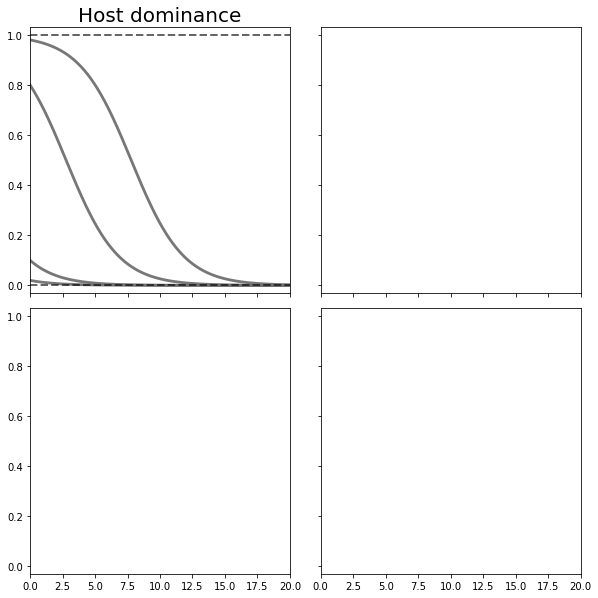

In [9]:
COL = {
    "host":    "#707071",
    "coexist": "#629FB7",
    "bistab":  "#106E91",
    "cancer":  "#AF4772",
}

# Representative parameters (one per quadrant)
cases = [
    ("Host dominance",      -0.5, +0.5, COL["host"]),
    ("Stable coexistence",  +0.5, +0.5, COL["coexist"]),
    ("Bistability",         -0.5, -0.5, COL["bistab"]),
    ("Cancer dominance",    +0.5, -0.5, COL["cancer"]),
]
# Initial conditions (several to show convergence)
x0s_general = [0.02, 0.10, 0.80, 0.98]
# show both basins + "just below/above" the unstable point (~0.5 here)
x0s_bistab  = [0.02, 0.20, 0.49, 0.51, 0.80, 0.98]

# Make Panel B square overall, so each small panel can be square and still large
fig, axs = plt.subplots(2, 2, figsize=(8.2, 8.2), sharex=True, sharey=True, constrained_layout=True)
axs = axs.ravel()

for ax, (name, a, b, color) in zip(axs, cases):
    x0s = x0s_bistab if "Bistability" in name else x0s_general

    for x0 in x0s:
        t, x = sigammalate(a, b, x0, tmax=20)
        ax.plot(t, x, lw=2.8, color=color, alpha=0.95)

    # equilibrium guides (keep subtle)
    ax.axhline(0, ls="--", lw=2, color="black", alpha=0.6)
    ax.axhline(1, ls="--", lw=2, color="black", alpha=0.6)
    xs = x_star(a, b)
    if xs is not None:
        ax.axhline(xs, ls="--", lw=2, color="black", alpha=0.6)

    ax.set_title(name, fontsize=20, pad=6)
    ax.set_xlim(0, 20)
    ax.set_ylim(-0.03, 1.03)

    # square subplot boxes
    ax.set_box_aspect(1)

    # integer-ish ticks on time, clean y ticks
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.tick_params(labelsize=12)

# axis labels (outer only)
axs[2].set_xlabel("Time", fontsize=18)
axs[3].set_xlabel("Time", fontsize=18)
axs[0].set_ylabel(r"Cancer fraction $x$", fontsize=20)
axs[2].set_ylabel(r"Cancer fraction $x$", fontsize=20)

plt.savefig("Figures/fig1B_trajectories.svg", bbox_inches="tight")
plt.savefig("Figures/fig1B_trajectories.png", dpi=600, bbox_inches="tight")

plt.show()


## Fig 3. Environmental feedback trajectories

In [ ]:
# ----------------------------
# Core model building blocks
# ----------------------------

@dataclass(frozen=True)
class GameEndpoints:
    """
    Reduced 2x2 payoff form:
        M = [[0, beta],
             [alpha, 0]]

    Endpoints:
      (alpha_h, beta_h) = baseline (low conditioning)
      (alpha_s, beta_s) = stressed (high conditioning)
    """
    alpha_h: float
    beta_h: float
    alpha_s: float
    beta_s: float


def endpoints_host_to_cancer(alpha: float, beta: float) -> GameEndpoints:
    """
    Scenario 1 mapping:
      baseline: host-dominant  (alpha<0, beta>0)
      stressed: cancer-dominant (alpha>0, beta<0)
    """
    return GameEndpoints(alpha_h=-alpha, beta_h=+beta,
                         alpha_s=+alpha, beta_s=-beta)


def endpoints_coexist_to_cancer(alpha: float, beta: float) -> GameEndpoints:
    """
    Scenario 2 mapping:
      baseline: stable coexistence (alpha>0, beta>0)
      stressed: cancer-dominant    (alpha>0, beta<0)
    """
    return GameEndpoints(alpha_h=+alpha, beta_h=+beta,
                         alpha_s=+alpha, beta_s=-beta)


def hill_gate(n, k: float, nu: float = 1.0):
    """
    f(n) = n^nu / (n^nu + k^nu) in [0,1]
    Vectorized.
    """
    n = np.asarray(n)
    n = np.maximum(n, 0.0)
    return (n**nu) / (n**nu + k**nu)


def alpha_beta(n, ends: GameEndpoints, k: float, nu: float = 1.0):
    """
    alpha(n) and beta(n) via interpolation:
      alpha(n) = (1-f) alpha_h + f alpha_s
      beta(n)  = (1-f) beta_h  + f beta_s
    Returns alpha, beta, f (all vectorized).
    """
    f = hill_gate(n, k, nu)
    alpha_n = (1 - f) * ends.alpha_h + f * ends.alpha_s
    beta_n  = (1 - f) * ends.beta_h  + f * ends.beta_s
    return alpha_n, beta_n, f


def rhs(t, y, ends: GameEndpoints, phi: float, gamma: float, k: float, nu: float):
    """
    y = [x, n]
      xdot = x(1-x)( alpha(n) - (alpha(n)+beta(n)) x )
      ndot = phi*x - gamma*n
    """
    x, n = y

    # keep numerics sane
    x = np.clip(x, 0.0, 1.0)
    n = max(n, 0.0)

    a, b, _ = alpha_beta(n, ends, k, nu)
    dx = x * (1 - x) * (a - (a + b) * x)
    dn = phi * x - gamma * n
    return [dx, dn]


def simulate_case(ends: GameEndpoints,
                  phi: float, gamma: float, k: float, nu: float,
                  x0: float, n0: float,
                  tmax: float = 80.0, npts: int = 2000):
    """
    Returns a dict with:
      t, x, n, alpha(t), beta(t), f(t)
    """
    t_eval = np.linspace(0, tmax, npts)
    sol = solve_ivp(
        rhs, (0, tmax), [x0, n0], t_eval=t_eval,
        args=(ends, phi, gamma, k, nu),
        rtol=1e-8, atol=1e-10
    )

    t = sol.t
    x = sol.y[0]
    n = sol.y[1]
    a, b, f = alpha_beta(n, ends, k, nu)

    return {"t": t, "x": x, "n": n, "alpha": a, "beta": b, "f": f}

# ----------------------------
# 4 default cases
# ----------------------------

@dataclass(frozen=True)
class Case:
    name: str
    ends: GameEndpoints
    phi: float
    gamma: float
    k: float
    nu: float
    tmax: float
    x0s: tuple
    n0: float


def build_default_cases():
    cases = {}

    # 1) Clearance (Scenario 1, rho_hat<1)
    cases["clearance"] = Case(
        name="Clearance",
        ends=endpoints_host_to_cancer(alpha=0.25, beta=0.5),
        phi=0.7, gamma=0.5, k=2.0, nu=1.0,
        tmax=80.0,
        x0s=(0.02, 0.10, 0.80, 0.98),
        n0=0.0
    )

    # 2) Stable dormancy / persistence (Scenario 2, rho_hat<1)
    cases["dormancy"] = Case(
        name="Stable dormancy",
        ends=endpoints_coexist_to_cancer(alpha=0.5, beta=0.5),
        phi=0.7, gamma=1.0, k=2.0, nu=1.0,
        tmax=50.0,
        x0s=(0.02, 0.10, 0.80, 0.98),
        n0=0.0
    )

    # 3) Awakening (Scenario 2, rho_hat>1)
    cases["awakening"] = Case(
        name="Awakening",
        ends=endpoints_coexist_to_cancer(alpha=0.1, beta=0.9),
        phi=0.09, gamma=0.02, k=2.0, nu=1.0,
        tmax=720.0,
        x0s=(0.02, 0.10, 0.40, 0.80),
        n0=0.0
    )

    # 4) Primed niche / invasion threshold (Scenario 1, rho_hat>1)
    # Show two initial conditions (your notebook: x0=0.2 vs 0.4)
    cases["primed_threshold"] = Case(
        name="Primed niche threshold",
        ends=endpoints_host_to_cancer(alpha=0.5, beta=0.6),
        phi=0.23, gamma=0.5, k=0.1, nu=1.0,
        tmax=50.0,
        x0s=(0.20, 0.40),
        n0=0.1
    )

    return cases

In [ ]:
# Match Fig1 palette
COL = {
    "host":    "#707071",
    "coexist": "#629FB7",
    "bistab":  "#106E91",
    "cancer":  "#AF4772",
}

# Choose one color per feedback case (feel free to change)
CASE_COLOR = {
    "clearance":        COL["host"],
    "dormancy":         COL["coexist"],
    "awakening":        COL["cancer"],
    "primed_threshold": COL["bistab"],
}

# Style knobs to match Fig1
LINE_W = 2.8
LINE_A = 0.95
DASH_W = 2.0
DASH_A = 0.6
TITLE_FS = 20
LABEL_FS = 20
XLABEL_FS = 18
TICK_FS = 12


def run_case(case, npts=2000):
    """Sigammalate all x0s for a Case. Returns list of dict outputs."""
    outs = []
    for x0 in case.x0s:
        out = simulate_case(
            case.ends,
            phi=case.phi, gamma=case.gamma, k=case.k, nu=case.nu,
            x0=x0, n0=case.n0,
            tmax=case.tmax, npts=npts
        )
        out["x0"] = x0
        outs.append(out)
    return outs


def _nice_ylim_n(case, outs):
    """Choose n-axis limits that always show 0 and the tolerance k line."""
    nmax = max(float(np.max(o["n"])) for o in outs)
    top = 1.05 * max(nmax, case.k)
    bottom = -0.03 * case.k  # tiny padding like your x axis
    return bottom, top


def plot_case_timeseries(case_key, case, outs, outdir="Figures",
                         layout="stack", label_x0=False):
    """
    Save ONE figure for ONE case.
    layout:
      - "stack": x(t) top, n(t) bottom
      - "twin" : x(t) left axis, n(t) right axis (same panel)
    """
    os.makedirs(outdir, exist_ok=True)
    color = CASE_COLOR.get(case_key, "black")

    if layout == "stack":
        fig, (ax_x, ax_n) = plt.subplots(
            2, 1, figsize=(6.2, 6.2), sharex=True, constrained_layout=True
        )

        # --- x(t) ---
        for o in outs:
            ax_x.plot(o["t"], o["x"], lw=LINE_W, color=color, alpha=LINE_A)
            if label_x0:
                ax_x.text(o["t"][int(0.03*len(o["t"]))], o["x"][int(0.03*len(o["x"]))],
                          f"{o['x0']:.2f}", fontsize=10, color=color)

        ax_x.axhline(0, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_x.axhline(1, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_x.set_ylim(-0.03, 1.03)
        ax_x.set_title(case.name, fontsize=TITLE_FS, pad=6)
        ax_x.set_ylabel(r"Cancer fraction $x$", fontsize=LABEL_FS)

        # --- n(t) ---
        for o in outs:
            ax_n.plot(o["t"], o["n"], lw=LINE_W, color=color, alpha=LINE_A)

        # tolerance line at n = k
        ax_n.axhline(case.k, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_n.set_ylabel(r"Conditioning $n$", fontsize=LABEL_FS)
        ax_n.set_xlabel("Time", fontsize=XLABEL_FS)
        nlo, nhi = _nice_ylim_n(case, outs)
        ax_n.set_ylim(nlo, nhi)

        # ticks (integer time, clean y)
        ax_n.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
        ax_x.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax_n.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax_x.tick_params(labelsize=TICK_FS)
        ax_n.tick_params(labelsize=TICK_FS)
        fig.align_ylabels([ax_x, ax_n])

        # Save
        base = os.path.join(outdir, f"fig3_{case_key}_{layout}")
        fig.savefig(base + ".svg", bbox_inches="tight")
        fig.savefig(base + ".png", dpi=600, bbox_inches="tight")
        plt.show()
        return base

    elif layout == "twin":
        fig, ax_x = plt.subplots(figsize=(6.2, 6.2), constrained_layout=True)
        ax_n = ax_x.twinx()

        # x(t)
        for o in outs:
            ax_x.plot(o["t"], o["x"], lw=LINE_W, color=color, alpha=LINE_A)
        ax_x.axhline(0, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_x.axhline(1, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_x.set_ylim(-0.03, 1.03)

        # n(t)
        for o in outs:
            ax_n.plot(o["t"], o["n"], lw=LINE_W, color="black", alpha=0.35)
        ax_n.axhline(case.k, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        nlo, nhi = _nice_ylim_n(case, outs)
        ax_n.set_ylim(nlo, nhi)

        ax_x.set_title(case.name, fontsize=TITLE_FS, pad=6)
        ax_x.set_xlabel("Time", fontsize=XLABEL_FS)
        ax_x.set_ylabel(r"Cancer fraction $x$", fontsize=LABEL_FS)
        ax_n.set_ylabel(r"Conditioning $n$", fontsize=LABEL_FS)

        ax_x.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
        ax_x.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax_n.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax_x.tick_params(labelsize=TICK_FS)
        ax_n.tick_params(labelsize=TICK_FS)
        fig.align_ylabels([ax_x, ax_n])

        base = os.path.join(outdir, f"fig3_{case_key}_{layout}")
        fig.savefig(base + ".svg", bbox_inches="tight")
        fig.savefig(base + ".png", dpi=600, bbox_inches="tight")
        plt.show()
        return base

    else:
        raise ValueError("layout gammast be 'stack' or 'twin'")

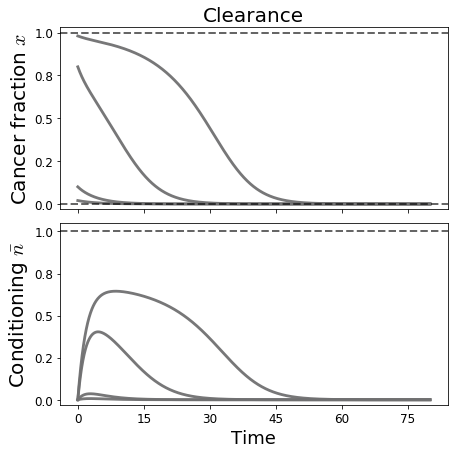

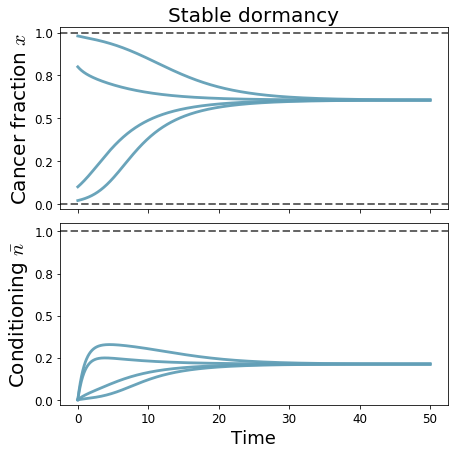

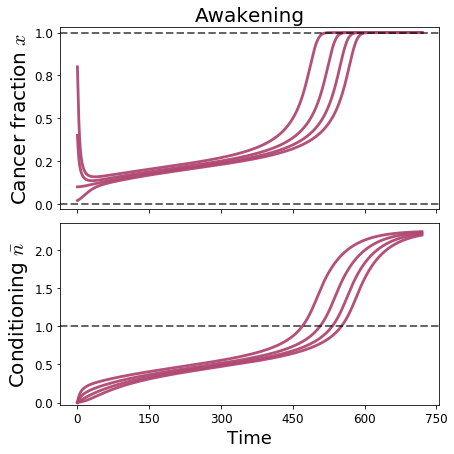

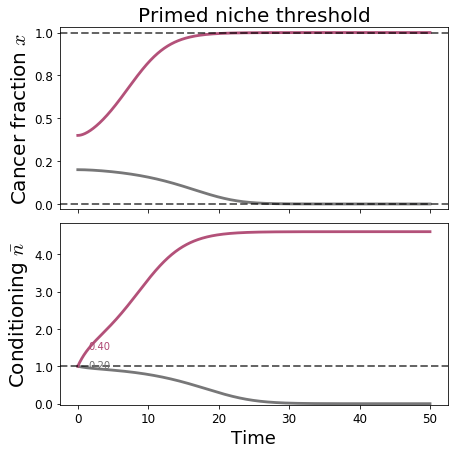

In [10]:
# -------------------------
# Example usage
# -------------------------
cases = build_default_cases()
all_outs = {}
# one-by-one (recommended)
for key in ["clearance", "dormancy", "awakening", "primed_threshold"]:
    case = cases[key]
    outs = run_case(case, npts=2000)
    all_outs[key] = outs
    # stacked plots (x above, n below)
    # layout = stack OR twin
    plot_case_timeseries(key, case, outs, outdir="Figures", layout="stack",
                         label_x0=(key == "primed_threshold"))

    # If twin-axis versions too:
    #plot_case_timeseries("awakening", cases["awakening"], run_case(cases["awakening"]),
    #                  outdir="Figures", layout="twin")


## Checking $\alpha$ and $\beta$ timeseries

Key = clearance
x0=0.02


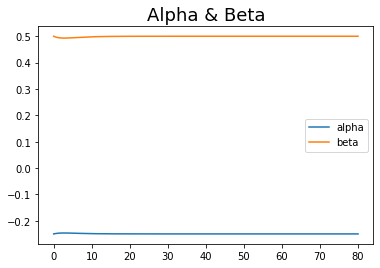

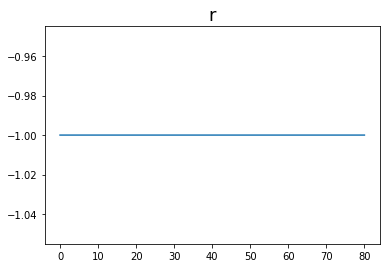

x0=0.1


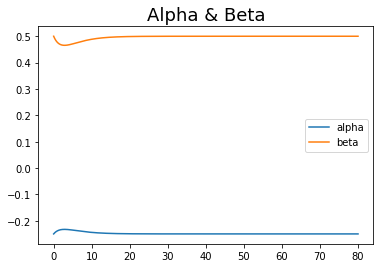

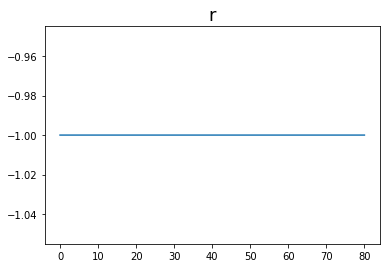

x0=0.8


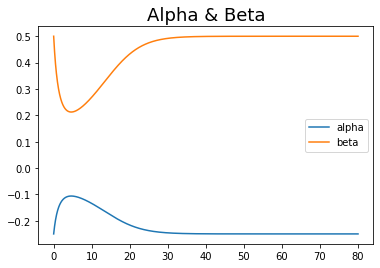

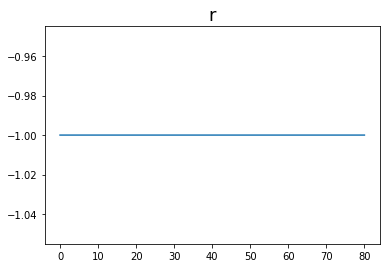

x0=0.98


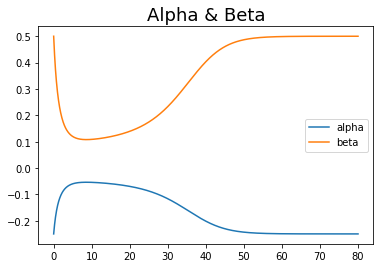

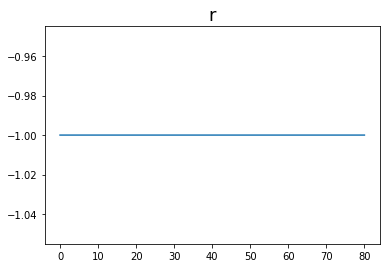

Key = dormancy
x0=0.02


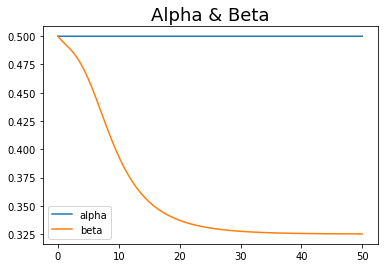

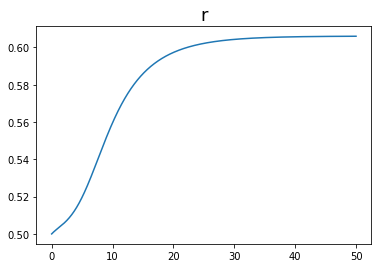

x0=0.1


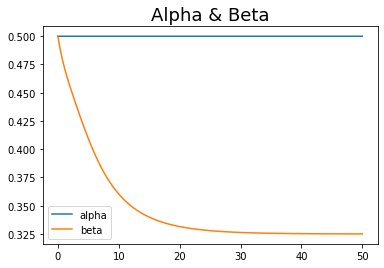

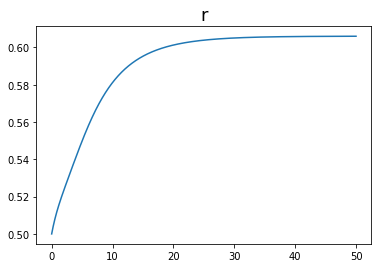

x0=0.8


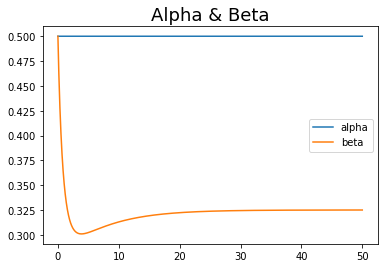

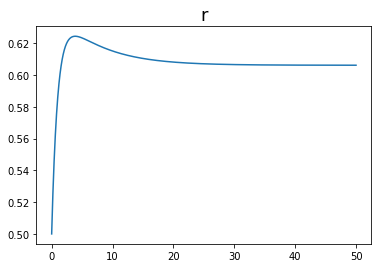

x0=0.98


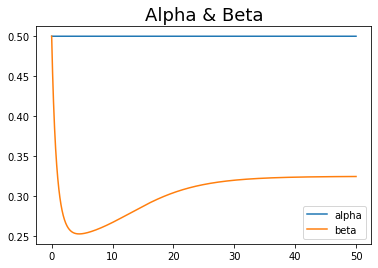

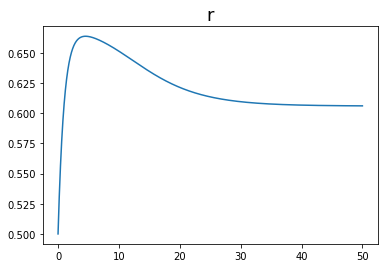

Key = awakening
x0=0.02


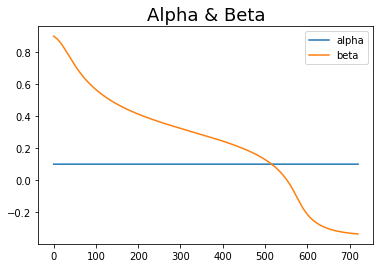

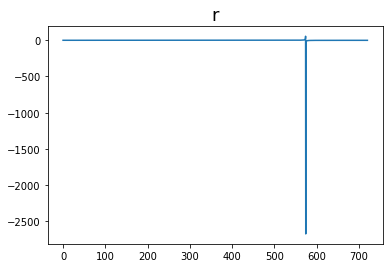

x0=0.1


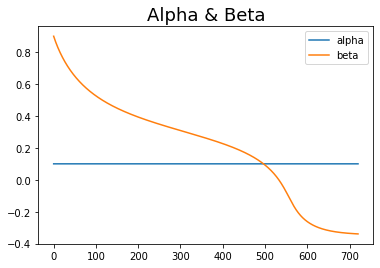

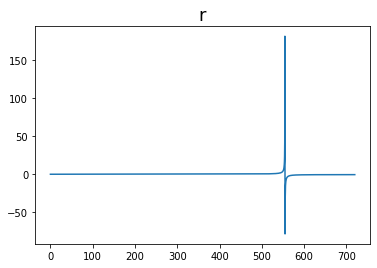

x0=0.4


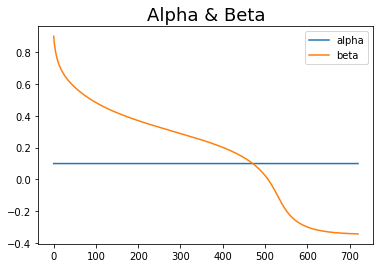

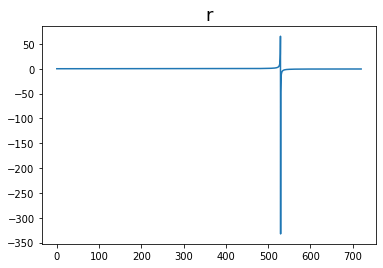

x0=0.8


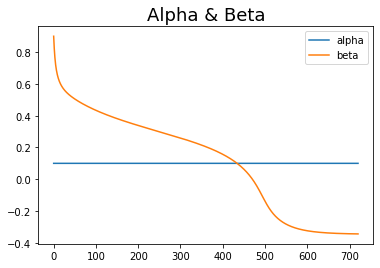

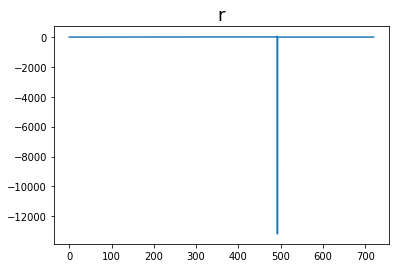

Key = primed_threshold
x0=0.2


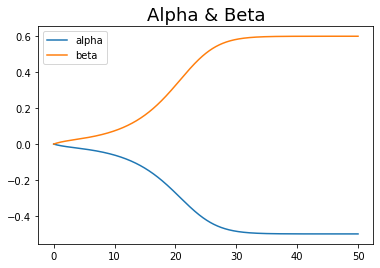

/Users/guillermo/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:11: RuntimeWarning: invalid value encountered in true_divide
  # This is added back by InteractiveShellApp.init_path()


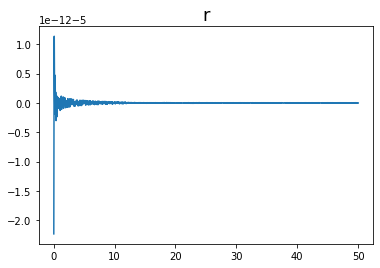

x0=0.4


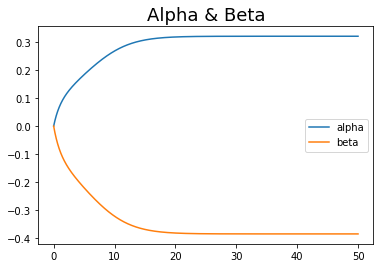

/Users/guillermo/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:11: RuntimeWarning: invalid value encountered in true_divide
  # This is added back by InteractiveShellApp.init_path()


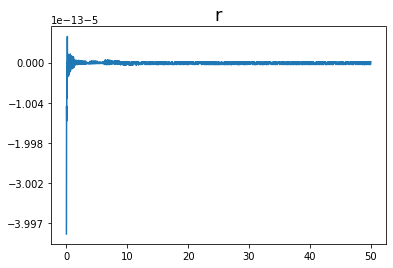

In [11]:
keys = ['clearance', 'dormancy', 'awakening', 'primed_threshold']
for key in keys:
    print(f"Key = {key}")
    for case in all_outs[key]:
        print(f"x0={case['x0']}")
        plt.plot(case['t'],case['alpha'], label='alpha')
        plt.plot(case['t'],case['beta'], label='beta')
        plt.title('Alpha & Beta',fontsize=18)
        plt.legend()
        plt.show()
        plt.plot(case['t'],case['alpha']/(case['alpha']+case['beta']))
        plt.title('r',fontsize=18)
        plt.show()

## Fig 3. (Nondimensional, reparametrized) Environmental feedback trajectories

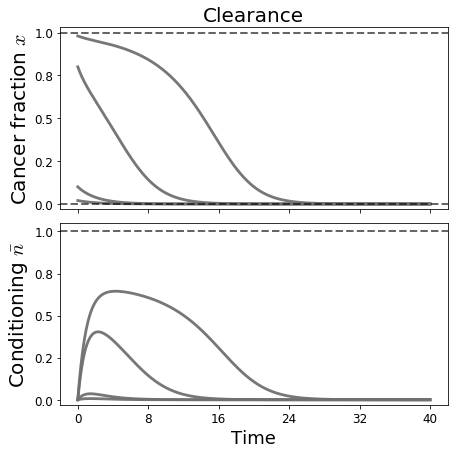

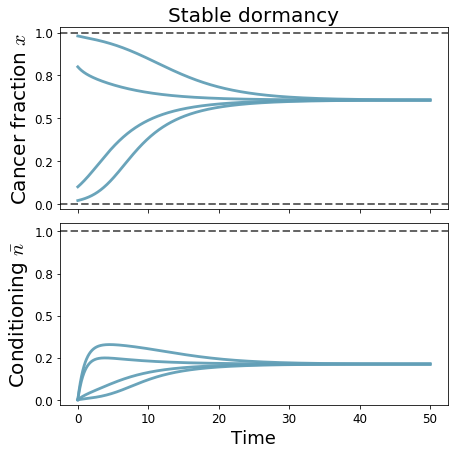

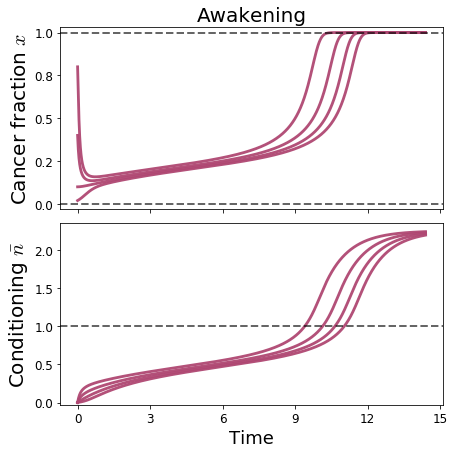

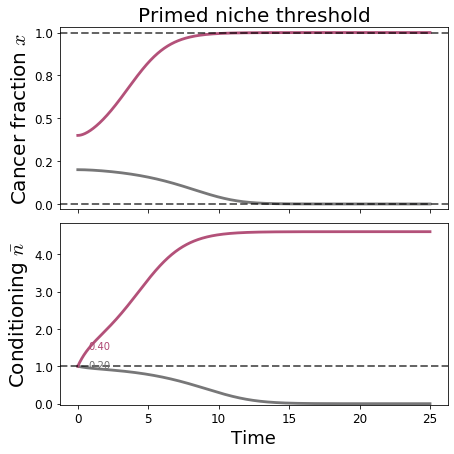

In [12]:
# ----------------------------
# Core model building blocks (NON-DIMENSIONAL STATE; INTEGRATE IN t)
#   state: (x, n̄) with n̄ = n/k
#   parameter: φ̄ = φ/(γ k)
#   integrate in dimensional t
#   option to plot either t or τ=γt
# ----------------------------

@dataclass(frozen=True)
class GameEndpoints:
    """
    Reduced 2x2 payoff-difference form:
        M = [[0, beta],
             [alpha, 0]]

    Endpoints:
      (alpha_h, beta_h) = baseline (low conditioning)
      (alpha_s, beta_s) = stressed  (high conditioning)
    """
    alpha_h: float
    beta_h: float
    alpha_s: float
    beta_s: float


def endpoints_host_to_cancer(alpha: float, beta: float) -> GameEndpoints:
    """
    Scenario 1 mapping:
      baseline: host-dominant   (alpha<0, beta>0)
      stressed: cancer-dominant (alpha>0, beta<0)
    """
    return GameEndpoints(alpha_h=-alpha, beta_h=+beta,
                         alpha_s=+alpha, beta_s=-beta)


def endpoints_coexist_to_cancer(alpha: float, beta: float) -> GameEndpoints:
    """
    Scenario 2 mapping:
      baseline: stable coexistence (alpha>0, beta>0)
      stressed: cancer-dominant    (alpha>0, beta<0)
    """
    return GameEndpoints(alpha_h=+alpha, beta_h=+beta,
                         alpha_s=+alpha, beta_s=-beta)


def hill_gate_bar(n_bar, nu: float = 1.0):
    """
    Non-dimensional Hill gate:
        f(n̄) = n̄^nu / (1 + n̄^nu)   in [0,1]
    Vectorized.
    """
    n_bar = np.asarray(n_bar)
    n_bar = np.maximum(n_bar, 0.0)
    return (n_bar**nu) / (1.0 + n_bar**nu)


def alpha_beta_bar(n_bar, ends: GameEndpoints, nu: float = 1.0):
    """
    alpha(n̄) and beta(n̄) via interpolation:
      alpha(n̄) = (1-f) alpha_h + f alpha_s
      beta(n̄)  = (1-f) beta_h  + f beta_s
    Returns alpha, beta, f (vectorized).
    """
    f = hill_gate_bar(n_bar, nu)
    alpha_n = (1 - f) * ends.alpha_h + f * ends.alpha_s
    beta_n  = (1 - f) * ends.beta_h  + f * ends.beta_s
    return alpha_n, beta_n, f


def rhs_t(t, y_bar, ends: GameEndpoints, phi_bar: float, gamma: float, nu: float):
    """
    Integrate in dimensional time t, but with non-dimensional conditioning state n̄=n/k.

      dx/dt     = x(1-x)[ alpha(n̄) - (alpha(n̄)+beta(n̄)) x ]
      dn̄/dt    = γ( φ̄ x - n̄ )     with φ̄ = φ/(γk)

    y_bar = [x, n̄]
    """
    x, n_bar = y_bar
    x = float(np.clip(x, 0.0, 1.0))
    n_bar = float(max(n_bar, 0.0))

    a, b, _ = alpha_beta_bar(n_bar, ends, nu)
    a = float(a); b = float(b)

    dx = x * (1 - x) * (a - (a + b) * x)
    dnbar = gamma * (phi_bar * x - n_bar)
    return [dx, dnbar]


def simulate_case_nondim(ends: GameEndpoints,
                         phi: float, gamma: float, k: float, nu: float,
                         x0: float, n0: float,
                         tmax: float = 80.0, npts: int = 2000):
    """
    Integrate the equations in dimensional time t, using n̄=n/k internally.
    Return both t and τ=γt, and both n̄ and n.

    Returns dict with:
      t, tau, x, nbar, n,
      alpha(t), beta(t), f(t),
      s(t)=alpha+beta, r(t)=alpha/s (NaN if s≈0),
      Lambda(t)=s/gamma, phi_bar
    """
    phi_bar = phi / (gamma * k)
    n0_bar = n0 / k

    t_eval = np.linspace(0.0, tmax, npts)

    sol = solve_ivp(
        rhs_t, (0.0, tmax), [x0, n0_bar],
        t_eval=t_eval,
        args=(ends, phi_bar, gamma, nu),
        rtol=1e-8, atol=1e-10
    )

    t = sol.t
    x = sol.y[0]
    nbar = sol.y[1]

    tau = gamma * t
    n = k * nbar

    a, b, f = alpha_beta_bar(nbar, ends, nu)
    s = a + b

    r = np.full_like(s, np.nan, dtype=float)
    mask = np.abs(s) > 1e-12
    r[mask] = a[mask] / s[mask]

    Lambda = s / gamma  # instantaneous selection/clearance ratio

    return {
        "t": t, "tau": tau,
        "x": x, "nbar": nbar, "n": n,
        "alpha": a, "beta": b, "f": f,
        "s": s, "r": r, "Lambda": Lambda,
        "phi_bar": phi_bar
    }


# ----------------------------
# 4 default cases (same API; phi_bar and nbar computed internally)
# ----------------------------

@dataclass(frozen=True)
class Case:
    name: str
    ends: GameEndpoints
    phi: float
    gamma: float
    k: float
    nu: float
    tmax: float
    x0s: tuple
    n0: float


def build_default_cases():
    cases = {}

    # 1) Clearance (Scenario 1, phi_bar < 1)
    cases["clearance"] = Case(
        name="Clearance",
        ends=endpoints_host_to_cancer(alpha=0.25, beta=0.5),
        phi=0.7, gamma=0.5, k=2.0, nu=1.0,
        tmax=80.0,
        x0s=(0.02, 0.10, 0.80, 0.98),
        n0=0.0
    )

    # 2) Stable dormancy / persistence (Scenario 2, phi_bar < 1)
    cases["dormancy"] = Case(
        name="Stable dormancy",
        ends=endpoints_coexist_to_cancer(alpha=0.5, beta=0.5),
        phi=0.7, gamma=1.0, k=2.0, nu=1.0,
        tmax=50.0,
        x0s=(0.02, 0.10, 0.80, 0.98),
        n0=0.0
    )

    # 3) Awakening (Scenario 2, phi_bar > 1)
    cases["awakening"] = Case(
        name="Awakening",
        ends=endpoints_coexist_to_cancer(alpha=0.1, beta=0.9),
        phi=0.09, gamma=0.02, k=2.0, nu=1.0,
        tmax=720.0,
        x0s=(0.02, 0.10, 0.40, 0.80),
        n0=0.0
    )

    # 4) Primed niche / invasion threshold (Scenario 1, phi_bar > 1)
    cases["primed_threshold"] = Case(
        name="Primed niche threshold",
        ends=endpoints_host_to_cancer(alpha=0.5, beta=0.6),
        phi=0.23, gamma=0.5, k=0.1, nu=1.0,
        tmax=50.0,
        x0s=(0.20, 0.40),
        n0=0.1
    )

    return cases


# ----------------------------
# Plot styling (match Fig1)
# ----------------------------

COL = {
    "host":    "#707071",
    "coexist": "#629FB7",
    "bistab":  "#106E91",
    "cancer":  "#AF4772",
}

CASE_COLOR = {
    "clearance":        COL["host"],
    "dormancy":         COL["coexist"],
    "awakening":        COL["cancer"],
    "primed_threshold": COL["bistab"],
}

LINE_W = 2.8
LINE_A = 0.95
DASH_W = 2.0
DASH_A = 0.6
TITLE_FS = 20
LABEL_FS = 20
XLABEL_FS = 18
TICK_FS = 12


def run_case(case: Case, npts=2000):
    """Simulate all x0s for a Case. Returns list of dict outputs."""
    outs = []
    for x0 in case.x0s:
        out = simulate_case_nondim(
            case.ends,
            phi=case.phi, gamma=case.gamma, k=case.k, nu=case.nu,
            x0=x0, n0=case.n0,
            tmax=case.tmax, npts=npts
        )
        out["x0"] = x0
        outs.append(out)
    return outs


def _nice_ylim_nbar(outs):
    """n̄-axis limits; always include 0 and show tolerance line at n̄=1."""
    nbar_max = max(float(np.max(o["nbar"])) for o in outs)
    top = 1.05 * max(nbar_max, 1.0)
    bottom = -0.03
    return bottom, top


def plot_case_timeseries(case_key, case: Case, outs, outdir="Figures",
                         layout="stack", time_axis="t", label_x0=False):
    """
    Save ONE figure for ONE case.

    layout:
      - "stack": x(top), n̄(bottom)
      - "twin" : x left axis, n̄ right axis (same panel)

    time_axis:
      - "t"   : dimensional time t
      - "tau" : scaled time τ = γ t
    """
    os.makedirs(outdir, exist_ok=True)
    color = CASE_COLOR.get(case_key, "black")

    def _T(o):
        return o["t"] if time_axis == "t" else o["tau"]

    def _curve_color(o):
        if case_key == "primed_threshold":
            # classify by final state (robust + zero extra bookkeeping)
            return COL["cancer"] if o["x"][-1] > 0.5 else COL["host"]
        return CASE_COLOR.get(case_key, "black")
    
    xlab = "Time" if time_axis == "t" else "Time"

    if layout == "stack":
        fig, (ax_x, ax_n) = plt.subplots(
            2, 1, figsize=(6.2, 6.2), sharex=True, constrained_layout=True
        )

        # --- x(t) ---
        for o in outs:
            c = _curve_color(o)
            ax_x.plot(_T(o), o["x"], lw=LINE_W, color=c, alpha=LINE_A)

        ax_x.axhline(0, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_x.axhline(1, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_x.set_ylim(-0.03, 1.03)
        ax_x.set_title(case.name, fontsize=TITLE_FS, pad=6)
        ax_x.set_ylabel(r"Cancer fraction $x$", fontsize=LABEL_FS)

        # --- n̄(t) ---
        for o in outs:
            c = _curve_color(o)
            ax_n.plot(_T(o), o["nbar"], lw=LINE_W, color=c, alpha=LINE_A)
            if label_x0:
                i = int(0.03 * len(_T(o)))
                ax_n.text(_T(o)[i], o["nbar"][i], f"{o['x0']:.2f}",
                          fontsize=10, color=c)

        ax_n.axhline(1.0, ls="--", lw=DASH_W, color="black", alpha=DASH_A)  # tolerance at n̄=1
        ax_n.set_ylabel(r"Conditioning $\bar n$", fontsize=LABEL_FS)
        ax_n.set_xlabel(xlab, fontsize=XLABEL_FS)
        nlo, nhi = _nice_ylim_nbar(outs)
        ax_n.set_ylim(nlo, nhi)

        # ticks: integer-ish on x; fixed-format y to keep label widths aligned
        ax_n.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
        ax_x.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax_n.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax_x.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
        ax_n.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
        ax_x.tick_params(labelsize=TICK_FS)
        ax_n.tick_params(labelsize=TICK_FS)
        fig.align_ylabels([ax_x, ax_n])

        base = os.path.join(outdir, f"fig3_{case_key}_{layout}_{time_axis}")
        fig.savefig(base + ".svg", bbox_inches="tight")
        fig.savefig(base + ".png", dpi=600, bbox_inches="tight")
        plt.show()
        return base

    elif layout == "twin":
        fig, ax_x = plt.subplots(figsize=(6.2, 6.2), constrained_layout=True)
        ax_n = ax_x.twinx()

        for o in outs:
            c = _curve_color(o)
            ax_x.plot(_T(o), o["x"], lw=LINE_W, color=c, alpha=LINE_A)
        ax_x.axhline(0, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_x.axhline(1, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_x.set_ylim(-0.03, 1.03)

        for o in outs:
            c = _curve_color(o)
            ax_n.plot(_T(o), o["nbar"], lw=LINE_W, color="black", alpha=0.30)
        ax_n.axhline(1.0, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        nlo, nhi = _nice_ylim_nbar(outs)
        ax_n.set_ylim(nlo, nhi)

        ax_x.set_title(case.name, fontsize=TITLE_FS, pad=6)
        ax_x.set_xlabel(xlab, fontsize=XLABEL_FS)
        ax_x.set_ylabel(r"Cancer fraction $x$", fontsize=LABEL_FS)
        ax_n.set_ylabel(r"Conditioning $\bar n$", fontsize=LABEL_FS)

        ax_x.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
        ax_x.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax_n.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax_x.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
        ax_n.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
        ax_x.tick_params(labelsize=TICK_FS)
        ax_n.tick_params(labelsize=TICK_FS)
        fig.align_ylabels([ax_x, ax_n])

        base = os.path.join(outdir, f"fig3_{case_key}_{layout}_{time_axis}")
        fig.savefig(base + ".svg", bbox_inches="tight")
        fig.savefig(base + ".png", dpi=600, bbox_inches="tight")
        plt.show()
        return base

    else:
        raise ValueError("layout must be 'stack' or 'twin'.")


# -------------------------
# Example usage (one-by-one)
# -------------------------

cases = build_default_cases()

for key in ["clearance", "dormancy", "awakening", "primed_threshold"]:
    case = cases[key]
    outs = run_case(case, npts=2000)

    # Integrate in t, but choose what you plot on the x-axis here:
    plot_case_timeseries(
        key, case, outs,
        outdir="Figures",
        layout="stack",
        time_axis="tau",      # "t" or "tau"
        label_x0=(key == "primed_threshold")
    )


### Fig 4. Phase portraits

In [13]:
# ============================================================
# FIGURE 4 — Phase portraits in (x, n̄)
# It reuses:
#   - hill_gate_bar, alpha_beta_bar, rhs_t
#   - Case, build_default_cases, run_case
#   - COL, CASE_COLOR, LINE_W, LINE_A, DASH_W, DASH_A, TITLE_FS, LABEL_FS, TICK_FS
# ============================================================
"""
from scipy.optimize import brentq
import numpy as np
import matplotlib.pyplot as plt
import os


# ---------- helpers: analytic Jacobian + stability classification ----------

def _df_dnbar(nbar, nu: float):
    """Derivative of f(n̄)=n̄^ν/(1+n̄^ν) wrt n̄."""
    nbar = np.asarray(nbar, dtype=float)
    nbar = np.maximum(nbar, 0.0)
    if np.isclose(nu, 1.0):
        return 1.0 / (1.0 + nbar)**2

    u = nbar**nu
    uprime = nu * np.where(nbar > 0.0, nbar**(nu - 1.0), 0.0)
    return uprime / (1.0 + u)**2


def jacobian_at(x, nbar, ends: GameEndpoints, phi_bar: float, gamma: float, nu: float):
    """
    Jacobian of:
      dx/dt   = x(1-x)[a(n̄) - (a(n̄)+b(n̄)) x]
      dn̄/dt  = γ(φ̄ x - n̄)
    at (x, n̄).
    """
    x = float(x)
    nbar = float(max(nbar, 0.0))

    # gate and its derivative
    f = float(hill_gate_bar(nbar, nu))
    df = float(_df_dnbar(nbar, nu))

    # a(n̄), b(n̄) and derivatives wrt n̄ (since a,b are linear in f)
    a = (1 - f) * ends.alpha_h + f * ends.alpha_s
    b = (1 - f) * ends.beta_h  + f * ends.beta_s
    da = df * (ends.alpha_s - ends.alpha_h)
    db = df * (ends.beta_s  - ends.beta_h)

    s = a + b
    g = x * (1 - x)           # g(x)
    h = a - s * x             # h(x,n̄)

    # partials for dx
    dxdx = (1 - 2*x) * h + g * (-s)
    dxdn = g * (da - (da + db) * x)

    # partials for dn̄
    dndx = gamma * phi_bar
    dndn = -gamma

    return np.array([[dxdx, dxdn],
                     [dndx, dndn]], dtype=float)


def classify_fixed_point(J, tol=1e-10):
    eig = np.linalg.eigvals(J)
    re = np.real(eig)
    if np.all(re < -tol):
        return "stable", eig
    if np.all(re > tol):
        return "unstable", eig
    if (np.any(re > tol) and np.any(re < -tol)):
        return "saddle", eig
    return "neutral", eig


# ---------- interior fixed points: solve x = r(n̄), n̄ = φ̄ x ----------

def _r_of_nbar(nbar, ends: GameEndpoints, nu: float):
    a, b, _ = alpha_beta_bar(nbar, ends, nu)
    s = a + b
    # undefined when s=0
    if np.any(np.abs(s) < 1e-12):
        return np.nan
    r = a / s
    # only meaningful as an interior x-nullcline when r in (0,1)
    if np.any((r <= 0) | (r >= 1)):
        return np.nan
    return float(r)


def interior_fixed_points(ends: GameEndpoints, phi_bar: float, nu: float, y_max: float, n_scan=4000):
    """
    Find interior equilibria by solving:
      x = r(n̄) = a(n̄)/(a(n̄)+b(n̄))
      n̄ = φ̄ x  -> x = n̄/φ̄
    so roots of: r(n̄) - n̄/φ̄ = 0  over n̄ ∈ [0, min(y_max, φ̄)].
    """
    if phi_bar <= 0:
        return []

    upper = min(y_max, phi_bar)
    if upper <= 0:
        return []

    ngrid = np.linspace(0.0, upper, n_scan)

    # compute r on a grid (vectorized), then scan sign changes robustly
    a, b, _ = alpha_beta_bar(ngrid, ends, nu)
    s = a + b
    r = np.full_like(ngrid, np.nan, dtype=float)
    mask = np.abs(s) > 1e-12
    r[mask] = a[mask] / s[mask]

    valid = mask & (r > 0.0) & (r < 1.0)
    F = np.full_like(ngrid, np.nan, dtype=float)
    F[valid] = r[valid] - (ngrid[valid] / phi_bar)

    roots = []
    for i in range(len(ngrid) - 1):
        f0, f1 = F[i], F[i+1]
        if not (np.isfinite(f0) and np.isfinite(f1)):
            continue
        if f0 == 0.0:
            nroot = float(ngrid[i])
        elif f0 * f1 < 0:
            # bracketed root
            a0, a1 = float(ngrid[i]), float(ngrid[i+1])

            def G(nn):
                rr = _r_of_nbar(nn, ends, nu)
                if not np.isfinite(rr):
                    # brentq shouldn't wander here if the bracket is good,
                    # but guard anyway
                    return np.sign(f0) * 1e6
                return rr - nn / phi_bar

            try:
                nroot = float(brentq(G, a0, a1, maxiter=200))
            except Exception:
                continue
        else:
            continue

        xroot = nroot / phi_bar
        if 0.0 < xroot < 1.0 and 0.0 <= nroot <= y_max:
            if not any(abs(nroot - rr[1]) < 1e-4 for rr in roots):
                roots.append((xroot, nroot))

    return roots


# ---------- separatrix (stable manifold) for saddles (optional) ----------

def rhs_t_raw(t, y_bar, ends: GameEndpoints, phi_bar: float, gamma: float, nu: float):
    """Same as rhs_t, but without clipping x (better for manifold tracing)."""
    x, nbar = y_bar
    nbar_eff = max(float(nbar), 0.0)
    a, b, _ = alpha_beta_bar(nbar_eff, ends, nu)
    a = float(a); b = float(b)
    dx = x * (1 - x) * (a - (a + b) * x)
    dn = gamma * (phi_bar * x - nbar)
    return [dx, dn]


def trace_stable_manifold(ax, x_s, n_s, ends, phi_bar, gamma, nu, y_max,
                          T=200.0, npts=2000, eps=1e-4, lw=1.8, alpha=0.8):
    """
    Trace stable manifold of a saddle by integrating BACKWARD from
    x_s ± eps*v_stable, where v_stable is eigenvector of negative eigenvalue.
    """
    J = jacobian_at(x_s, n_s, ends, phi_bar, gamma, nu)
    w, V = np.linalg.eig(J)
    # pick eigenvector with most negative real part
    idx = np.argmin(np.real(w))
    v = np.real(V[:, idx])
    v = v / np.linalg.norm(v)

    t_eval = np.linspace(0.0, -T, npts)

    for sgn in (+1.0, -1.0):
        y0 = [x_s + sgn * eps * v[0], n_s + sgn * eps * v[1]]

        sol = solve_ivp(
            rhs_t_raw, (0.0, -T), y0,
            t_eval=t_eval,
            args=(ends, phi_bar, gamma, nu),
            rtol=1e-8, atol=1e-10
        )
        xw = sol.y[0]
        nw = sol.y[1]

        # keep only the part inside the plotting domain
        m = (xw >= 0.0) & (xw <= 1.0) & (nw >= 0.0) & (nw <= y_max)
        ax.plot(xw[m], nw[m], color="black", lw=lw, alpha=alpha)


# ---------- main plotting function ----------

def plot_phase_portrait(case_key: str,
                        case: Case,
                        outs,
                        outdir="Figures",
                        figsize=(6.2, 6.2),
                        y_max=None,
                        grid_nx=23,
                        grid_ny=23,
                        show_vectorfield=True,
                        show_nullclines=True,
                        show_fixedpoints=True,
                        show_separatrix=True,
                        title=None,
                        hide_ticks=False):
    """
    Phase portrait in (x, n̄) for one Case.
    Uses trajectories in `outs` (from run_case) to overlay consistent paths.
    """
    os.makedirs(outdir, exist_ok=True)

    phi_bar = case.phi / (case.gamma * case.k)
    gamma = case.gamma
    nu = case.nu

    # auto y-range: always show n̄=1 and the fixed point (1, φ̄)
    nbar_peak = max(float(np.max(o["nbar"])) for o in outs)
    if y_max is None:
        y_max = 1.05 * max(1.0, phi_bar, nbar_peak)
    else:
        y_max = max(float(y_max), 1.05 * max(1.0, phi_bar))

    # curve color logic (match Fig3)
    def _curve_color(o):
        if case_key == "primed_threshold":
            return COL["cancer"] if o["x"][-1] > 0.5 else COL["host"]
        return CASE_COLOR.get(case_key, "black")

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    # --- vector field (light) ---
    if show_vectorfield:
        xs = np.linspace(0.0, 1.0, grid_nx)
        ns = np.linspace(0.0, y_max, grid_ny)
        X, N = np.meshgrid(xs, ns)

        # vectorized field
        a, b, _ = alpha_beta_bar(N, case.ends, nu)
        DX = X * (1 - X) * (a - (a + b) * X)
        DN = gamma * (phi_bar * X - N)

        # normalize for display (orientation only)
        S = np.sqrt(DX**2 + DN**2)
        S[S == 0] = 1.0
        U = DX / S
        V = DN / S

        ax.quiver(X, N, U, V,
                  color="0.55", alpha=0.45,
                  angles="xy", scale_units="xy", scale=18)

    # --- nullclines + tolerance ---
    if show_nullclines:
        # environmental nullcline: n̄ = φ̄ x
        xline = np.linspace(0.0, 1.0, 400)
        nline = phi_bar * xline
        m = nline <= y_max
        ax.plot(xline[m], nline[m], color="black", lw=2.0, alpha=0.9)

        # tolerance: n̄ = 1
        ax.axhline(1.0, ls="--", lw=DASH_W, color="black", alpha=DASH_A)

        # replicator interior nullcline: x = r(n̄)
        ngrid = np.linspace(0.0, y_max, 800)
        a, b, _ = alpha_beta_bar(ngrid, case.ends, nu)
        s = a + b
        r = np.full_like(ngrid, np.nan, dtype=float)
        mm = np.abs(s) > 1e-12
        r[mm] = a[mm] / s[mm]
        mm2 = mm & (r > 0.0) & (r < 1.0)
        ax.plot(r[mm2], ngrid[mm2], color="black", lw=2.2, alpha=0.9)

    # --- trajectories (same ICs as Fig3) ---
    for o in outs:
        c = _curve_color(o)
        # downsample for speed/cleanliness (esp. long runs)
        step = max(1, len(o["x"]) // 1200)
        ax.plot(o["x"][::step], o["nbar"][::step], lw=LINE_W, color=c, alpha=LINE_A)
        # initial point
        ax.plot(o["x"][0], o["nbar"][0],
                marker="o", ms=5, mfc="none", mec=c, mew=1.4, alpha=0.9)

    # --- fixed points ---
    saddles = []
    if show_fixedpoints:
        # boundary equilibria
        fps = [(0.0, 0.0), (1.0, float(phi_bar))]

        # interior equilibria (if any)
        fps += interior_fixed_points(case.ends, phi_bar, nu, y_max)

        for (xf, nf) in fps:
            if not (0.0 <= xf <= 1.0 and 0.0 <= nf <= y_max):
                continue

            J = jacobian_at(xf, nf, case.ends, phi_bar, gamma, nu)
            kind, _ = classify_fixed_point(J)

            if kind == "stable":
                ax.plot(xf, nf, marker="o", ms=7, mfc="black", mec="black", zorder=6)
            elif kind == "unstable":
                ax.plot(xf, nf, marker="o", ms=7, mfc="white", mec="black", mew=1.6, zorder=6)
            elif kind == "saddle":
                ax.plot(xf, nf, marker="*", ms=12, mfc="black", mec="black", zorder=7)
                saddles.append((xf, nf))
            else:
                ax.plot(xf, nf, marker="D", ms=7, mfc="white", mec="black", mew=1.3, zorder=6)

    # --- separatrix (stable manifold) for saddles (only really meaningful in threshold/bistable case) ---
    if show_separatrix and len(saddles) > 0:
        for (xs, ns) in saddles:
            trace_stable_manifold(ax, xs, ns, case.ends, phi_bar, gamma, nu, y_max,
                                  T=min(200.0, 2.0 * case.tmax),
                                  npts=2500, eps=2e-4, lw=1.8, alpha=0.85)

    # --- axes styling ---
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, y_max)

    if title is None:
        ax.set_title(case.name, fontsize=TITLE_FS, pad=6)
    else:
        ax.set_title(title, fontsize=TITLE_FS, pad=6)

    ax.set_xlabel(r"Cancer fraction $x$", fontsize=LABEL_FS)
    ax.set_ylabel(r"Conditioning $\bar n$", fontsize=LABEL_FS)

    ax.tick_params(labelsize=TICK_FS)
    if hide_ticks:
        ax.set_xticks([])
        ax.set_yticks([])

    base = os.path.join(outdir, f"fig4_{case_key}_phase")
    fig.savefig(base + ".svg", bbox_inches="tight")
    fig.savefig(base + ".png", dpi=600, bbox_inches="tight")
    plt.show()
    return base


# -------------------------
# Example usage: generate 4 phase portraits (one file per case)
# -------------------------

cases = build_default_cases()

for key in ["clearance", "dormancy", "awakening", "primed_threshold"]:
    case = cases[key]
    outs = run_case(case, npts=2000)  # reuse your Fig3 simulations
    plot_phase_portrait(
        key, case, outs,
        outdir="Figures",
        figsize=(6.2, 6.2),
        show_separatrix=(key == "primed_threshold"),  # only draw separatrix where you need it
        hide_ticks=False  # set True if you want to remove ticks (like your older paper)
    )
"""

SyntaxError: invalid syntax (<ipython-input-13-aedbd86cebe1>, line 18)

In [ ]:
# ============================
# FIG 4 — Phase portraits in (x, nbar)
# (append this AFTER your Fig 3 code cell)
# ============================

import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import brentq, minimize_scalar
from matplotlib.lines import Line2D

# ----------------------------
# Helpers (reuse your parameters)
# ----------------------------

def phi_bar(case: Case) -> float:
    """phi_bar = phi/(gamma*k)"""
    return case.phi / (case.gamma * case.k)


def rhs_tau(_tau, y, ends: GameEndpoints, phi_bar_val: float, gamma: float, nu: float):
    """
    Same phase curves as your rhs_t, but using tau = gamma t (uniform time rescale).
    This is often nicer numerically when gamma is very small.

      dx/dtau    = (1/gamma) x(1-x)[ a(nbar) - (a(nbar)+b(nbar)) x ]
      dnbar/dtau = phi_bar x - nbar
    """
    x, nbar = y
    x = float(np.clip(x, 0.0, 1.0))
    nbar = float(max(nbar, 0.0))

    a, b, _ = alpha_beta_bar(nbar, ends, nu)
    a = float(a); b = float(b)

    dx = (1.0 / gamma) * x * (1 - x) * (a - (a + b) * x)
    dn = phi_bar_val * x - nbar
    return [dx, dn]


def integrate_traj_tau(case: Case, x0: float, nbar0: float, tau_max=None, npts=1200):
    """Integrate one trajectory in tau-time and return arrays (x(tau), nbar(tau))."""
    if tau_max is None:
        tau_max = case.gamma * case.tmax

    pb = phi_bar(case)
    tau_eval = np.linspace(0.0, tau_max, npts)

    sol = solve_ivp(
        rhs_tau, (0.0, tau_max), [x0, nbar0],
        t_eval=tau_eval,
        args=(case.ends, pb, case.gamma, case.nu),
        rtol=1e-8, atol=1e-10
    )
    return sol.t, sol.y[0], sol.y[1]


def x_nullcline_curve(case: Case, nbar_vals: np.ndarray):
    """
    Interior x-nullcline from dx=0:
        x = a(nbar) / (a(nbar)+b(nbar))
    Return x*(nbar) with NaNs where undefined/outside (0,1).
    """
    a, b, _ = alpha_beta_bar(nbar_vals, case.ends, case.nu)
    s = a + b

    xstar = np.full_like(nbar_vals, np.nan, dtype=float)
    mask = np.abs(s) > 1e-12
    xstar[mask] = (a[mask] / s[mask]).astype(float)

    xstar[(xstar <= 0.0) | (xstar >= 1.0)] = np.nan
    return xstar


def fprime_hill(nbar: float, nu: float) -> float:
    """
    f(nbar)=nbar^nu/(1+nbar^nu)  ->  f'(nbar)= nu*nbar^(nu-1)/(1+nbar^nu)^2
    """
    nbar = float(max(nbar, 0.0))
    return nu * (nbar ** (nu - 1.0)) / ((1.0 + nbar ** nu) ** 2)


def jacobian_tau(case: Case, x: float, nbar: float) -> np.ndarray:
    """
    Jacobian of the tau-system:
      F = dx/dtau = (1/gamma)*x(1-x)[a - (a+b)x]
      G = dnbar/dtau = phi_bar*x - nbar

    J = [[Fx, Fn],
         [Gx, Gn]]
    """
    pb = phi_bar(case)
    gamma = case.gamma
    nu = case.nu
    ends = case.ends

    a, b, _ = alpha_beta_bar(nbar, ends, nu)
    a = float(a); b = float(b)

    # --- Fx: derivative wrt x holding a,b fixed ---
    # Let p(x)=x(1-x), q(x)=a-(a+b)x, F=(1/gamma)*p*q
    p = x * (1.0 - x)
    q = a - (a + b) * x
    dp = 1.0 - 2.0 * x
    dq = -(a + b)
    Fx = (1.0 / gamma) * (dp * q + p * dq)

    # --- Fn: derivative wrt nbar via a(nbar), b(nbar) ---
    fp = fprime_hill(nbar, nu)
    a_n = fp * (ends.alpha_s - ends.alpha_h)
    b_n = fp * (ends.beta_s  - ends.beta_h)
    s_n = a_n + b_n

    # q(nbar)=a - (a+b)x => dq/dnbar = a_n - s_n*x
    dq_n = a_n - s_n * x
    Fn = (1.0 / gamma) * (p * dq_n)

    # --- G derivatives ---
    Gx = pb
    Gn = -1.0

    return np.array([[Fx, Fn], [Gx, Gn]], dtype=float)


def classify_equilibrium(case: Case, x: float, nbar: float, tol=1e-8) -> str:
    eig = np.linalg.eigvals(jacobian_tau(case, x, nbar))
    re = np.real(eig)
    if np.all(re < -tol):
        return "stable"
    if np.all(re > tol):
        return "unstable"
    if re[0] * re[1] < -tol:
        return "saddle"
    return "neutral"


def find_interior_equilibria(case: Case):
    """
    Interior equilibria must satisfy:
      nbar = phi_bar*x
      x    = a(nbar)/(a(nbar)+b(nbar))
    => g(x)= x - a(phi_bar x)/(a(phi_bar x)+b(phi_bar x)) = 0
    """
    pb = phi_bar(case)
    ends = case.ends
    nu = case.nu

    def g(x):
        if not (0.0 < x < 1.0):
            return np.nan
        nbar = pb * x
        a, b, _ = alpha_beta_bar(nbar, ends, nu)
        s = float(a + b)
        if abs(s) < 1e-12:
            return np.nan
        xstar = float(a / s)
        return x - xstar

    xs = np.linspace(1e-4, 1 - 1e-4, 3000)
    gv = np.array([g(x) for x in xs])

    roots = []
    for i in range(len(xs) - 1):
        g1, g2 = gv[i], gv[i + 1]
        if np.isnan(g1) or np.isnan(g2):
            continue
        if g1 * g2 < 0:
            try:
                r = brentq(lambda z: g(z), xs[i], xs[i + 1], maxiter=200)
                roots.append(float(r))
            except Exception:
                pass

    # Tangency fallback (rare, but cheap)
    if len(roots) == 0:
        res = minimize_scalar(lambda z: abs(g(z)), bounds=(1e-4, 1 - 1e-4), method="bounded")
        if res.success and abs(g(res.x)) < 1e-6:
            roots.append(float(res.x))

    # unique + in (0,1)
    roots = sorted(set([r for r in roots if 0.0 < r < 1.0]))
    return [(r, pb * r) for r in roots]


def compute_equilibria(case: Case):
    """Return list of dicts with equilibrium coordinates + type."""
    pb = phi_bar(case)

    eqs = [
        {"x": 0.0, "nbar": 0.0},
        {"x": 1.0, "nbar": pb},
    ]
    for (xI, nI) in find_interior_equilibria(case):
        eqs.append({"x": xI, "nbar": nI})

    for e in eqs:
        e["kind"] = classify_equilibrium(case, e["x"], e["nbar"])
    return eqs


def add_arrows_along_line(ax, x, y, n_arrows=2, color="k", lw=1.6, alpha=0.95):
    """Put a few arrowheads along a polyline."""
    if len(x) < 10:
        return
    idx = np.linspace(10, len(x) - 2, n_arrows + 2, dtype=int)[1:-1]
    for i in idx:
        ax.annotate(
            "",
            xy=(x[i + 1], y[i + 1]),
            xytext=(x[i - 1], y[i - 1]),
            arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, alpha=alpha, shrinkA=0, shrinkB=0),
        )


def basin_map_euler(case: Case, ylim, nx=141, ny=141, tau_end=None, dtau=0.02):
    """
    Fast basin classification (for bistable case) using vectorized explicit Euler.
    Returns grid (X,Y) and basin labels Z in {0,1} (0=host, 1=cancer).
    """
    pb = phi_bar(case)
    if tau_end is None:
        tau_end = case.gamma * case.tmax

    xs = np.linspace(0.0, 1.0, nx)
    ys = np.linspace(ylim[0], ylim[1], ny)
    X, Y = np.meshgrid(xs, ys)

    x = X.copy()
    nbar = Y.copy()

    steps = int(tau_end / dtau)
    ends = case.ends
    nu = case.nu
    gamma = case.gamma

    for _ in range(steps):
        a, b, _ = alpha_beta_bar(nbar, ends, nu)
        dx = (1.0 / gamma) * x * (1 - x) * (a - (a + b) * x)
        dn = pb * x - nbar

        x = np.clip(x + dtau * dx, 0.0, 1.0)
        nbar = np.maximum(nbar + dtau * dn, 0.0)

    Z = (x > 0.5).astype(float)  # 1=cancer basin, 0=host basin
    return X, Y, Z


# ----------------------------
# Main plotting routine (one panel)
# ----------------------------

def plot_phase_portrait(
    ax,
    case_key: str,
    case: Case,
    *,
    quiver_n=(23, 23),
    nbar_ylim=None,
    n_ic=14,
    seed=0,
    show_legend=True,
    legend_loc="upper left",
    compute_basins_for_bistable=True,
    label_each_ic=False,
):
    pb = phi_bar(case)

    # y-limits
    if nbar_ylim is None:
        ymax = max(1.2, 1.15 * max(1.0, pb))
        nbar_ylim = (0.0, ymax)

    # ----- basin shading + separatrix (only for bistable / primed_threshold) -----
    if compute_basins_for_bistable and case_key == "primed_threshold":
        Xg, Yg, Z = basin_map_euler(case, nbar_ylim, nx=151, ny=151, dtau=0.02)
        ax.contourf(
            Xg, Yg, Z,
            levels=[-0.5, 0.5, 1.5],
            colors=[COL["host"], COL["cancer"]],
            alpha=0.12
        )
        # separatrix as basin boundary
        ax.contour(Xg, Yg, Z, levels=[0.5], colors="black", linewidths=2.2, alpha=0.9)

    # ----- vector field (direction only; normalized) -----
    xq = np.linspace(0.02, 0.98, quiver_n[0])
    yq = np.linspace(nbar_ylim[0], nbar_ylim[1], quiver_n[1])
    X, Y = np.meshgrid(xq, yq)

    a, b, _ = alpha_beta_bar(Y, case.ends, case.nu)
    dx = (1.0 / case.gamma) * X * (1 - X) * (a - (a + b) * X)
    dn = pb * X - Y

    speed = np.sqrt(dx * dx + dn * dn)
    dxn = np.where(speed > 0, dx / speed, 0.0)
    dnn = np.where(speed > 0, dn / speed, 0.0)

    ax.quiver(
        X, Y, dxn, dnn,
        angles="xy", scale_units="xy", scale=35,
        width=0.003, headwidth=3.5, headlength=4.5, headaxislength=4.0,
        color="black", alpha=0.6
    )

    # ----- nullclines -----
    # n-nullcline: nbar = pb * x
    xx = np.linspace(0.0, 1.0, 500)
    ax.plot(xx, pb * xx, ls="--", lw=2.0, color="black", alpha=0.6, label=r"$\dot{\bar n}=0$")

    # tolerance: nbar=1
    ax.axhline(1.0, ls="--", lw=2.0, color="black", alpha=0.35, label=r"$\bar n=1$")

    # x-nullcline interior branch: x = a/(a+b)
    nvals = np.linspace(nbar_ylim[0], nbar_ylim[1], 700)
    xstar = x_nullcline_curve(case, nvals)
    ax.plot(xstar, nvals, lw=2.0, color="black", alpha=0.85, label=r"$\dot x=0$")

    # ----- equilibria -----
    eqs = compute_equilibria(case)
    for e in eqs:
        xeq, yeq, kind = e["x"], e["nbar"], e["kind"]
        if kind == "stable":
            ax.plot(xeq, yeq, marker="o", ms=9, mfc="black", mec="white", mew=1.5, linestyle="None", zorder=7)
        elif kind == "saddle":
            ax.plot(xeq, yeq, marker="*", ms=14, mfc="black", mec="black", linestyle="None", zorder=8)
        elif kind == "unstable":
            ax.plot(xeq, yeq, marker="o", ms=9, mfc="white", mec="black", mew=1.5, linestyle="None", zorder=7)
        else:
            ax.plot(xeq, yeq, marker="s", ms=8, mfc="white", mec="black", linestyle="None", zorder=7)

    # ----- trajectories -----
    rng = np.random.default_rng(seed)
    xs0 = rng.uniform(0.05, 0.95, size=n_ic)
    ys0 = rng.uniform(nbar_ylim[0] + 0.02, nbar_ylim[1] - 0.02, size=n_ic)

    # a few deterministic ICs (helps reproducibility + shows structure)
    extra_x = np.array([0.1, 0.9, 0.5, 0.2, 0.8])
    extra_y = np.array([0.0, 0.0, 1.0, 0.2, min(nbar_ylim[1] * 0.8, nbar_ylim[1]-0.02)])
    xs0 = np.concatenate([xs0, extra_x])
    ys0 = np.concatenate([ys0, extra_y])

    tau_max = case.gamma * case.tmax
    base_color = CASE_COLOR.get(case_key, "black")

    for i, (x0, y0) in enumerate(zip(xs0, ys0)):
        _, xt, nt = integrate_traj_tau(case, float(x0), float(y0), tau_max=tau_max, npts=1200)

        # For primed_threshold: color by final basin (like your Fig.3 panel D logic)
        c = base_color
        if case_key == "primed_threshold":
            c = COL["cancer"] if xt[-1] > 0.5 else COL["host"]

        lab = None
        if label_each_ic:
            lab = rf"IC {i+1}: $(x_0,\bar n_0)=({x0:.2f},{y0:.2f})$"

        ax.plot(xt, nt, lw=2.2, color=c, alpha=0.92, zorder=5, label=lab)
        add_arrows_along_line(ax, xt, nt, n_arrows=2, color=c, lw=1.8, alpha=0.92)

        # mark initial condition
        ax.plot(xt[0], nt[0], marker="o", ms=5, mfc="white", mec=c, mew=1.4, linestyle="None", zorder=6)

    # ----- formatting -----
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(nbar_ylim[0], nbar_ylim[1])
    ax.set_title(case.name, fontsize=18, pad=6)
    ax.set_xlabel(r"$x$ (cancer fraction)", fontsize=14)
    ax.set_ylabel(r"$\bar n$ (environment state)", fontsize=14)
    ax.tick_params(labelsize=11)

    # ----- legend (everything has an entry; you can hide it) -----
    if show_legend and not label_each_ic:
        handles = [
            Line2D([0],[0], color="black", ls="--", lw=2.0, alpha=0.6, label=r"$\dot{\bar n}=0$  ($\bar n=\bar\phi x$)"),
            Line2D([0],[0], color="black", ls="-",  lw=2.0, alpha=0.85, label=r"$\dot x=0$  ($x=\alpha/(\alpha+\beta)$)"),
            Line2D([0],[0], color="black", ls="--", lw=2.0, alpha=0.35, label=r"tolerance ($\bar n=1$)"),
            Line2D([0],[0], marker="o", color="none", markerfacecolor="white", markeredgecolor="black",
                   markeredgewidth=1.5, markersize=7, label="initial condition"),
            Line2D([0],[0], marker="o", color="none", markerfacecolor="black", markeredgecolor="white",
                   markeredgewidth=1.5, markersize=8, label="stable equilibrium"),
            Line2D([0],[0], marker="*", color="none", markerfacecolor="black", markeredgecolor="black",
                   markersize=12, label="saddle"),
        ]

        if case_key == "primed_threshold" and compute_basins_for_bistable:
            handles += [
                Line2D([0],[0], color="black", lw=2.2, label="separatrix"),
                Line2D([0],[0], color=COL["host"],   lw=3, alpha=0.8, label="host basin"),
                Line2D([0],[0], color=COL["cancer"], lw=3, alpha=0.8, label="cancer basin"),
            ]
        else:
            handles += [Line2D([0],[0], color=base_color, lw=2.5, label="trajectories")]

        ax.legend(handles=handles, fontsize=9, loc=legend_loc, frameon=True)


# ----------------------------
# Build the 2x2 Figure 4 
# ----------------------------

def plot_fig4_phase_portraits(
    cases: dict,
    outdir="Figures",
    filename_base="fig4_phase_portraits",
    show_legend=False,
    label_each_ic=False,
):
    os.makedirs(outdir, exist_ok=True)

    fig, axs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
    order = ["clearance", "dormancy", "awakening", "primed_threshold"]

    for ax, key in zip(axs.ravel(), order):
        plot_phase_portrait(
            ax, key, cases[key],
            n_ic=14,
            seed=1,
            show_legend=show_legend,
            compute_basins_for_bistable=True,
            label_each_ic=label_each_ic
        )

    # Panel labels A–D (optional)
    for lab, ax in zip(["A", "B", "C", "D"], axs.ravel()):
        ax.text(-0.12, 1.05, lab, transform=ax.transAxes, fontsize=16, fontweight="bold", va="top")

    out_svg = os.path.join(outdir, filename_base + ".svg")
    out_png = os.path.join(outdir, filename_base + ".png")
    fig.savefig(out_svg, bbox_inches="tight")
    fig.savefig(out_png, dpi=600, bbox_inches="tight")
    plt.show()

    return out_svg, out_png


# ----------------------------
# Run
# ----------------------------

cases = build_default_cases()

plot_fig4_phase_portraits(
    cases,
    outdir="Figures",
    filename_base="fig4_phase_portraits",
    show_legend=True,        # set False for final export
    label_each_ic=False      # set True if want every IC in the legend (gets huge)
)
